In [42]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score 

In [43]:
##leemos el dataset 
df = pd.read_csv('boston.csv')
df.head()

## variable objetivo mtup price 

df.tail() 
df.describe()  # muestra una breve estadistica del data set 

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [44]:
'''calculo de correlacion  cerca de 1 relacion lineal fuerte y cerca de -1 relacion lineal negativa fuerte 
que variables se relacionan con la salida, detectamos multicolinealidad en las variables 
para evitar el sobreajuste '''  
np.round(df.corr(),2)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
CRIM,1.00,-0.20,0.41,-0.06,0.42,-0.22,0.35,-0.38,0.63,0.58,0.29,-0.39,0.46,-0.39
ZN,-0.20,1.00,-0.53,-0.04,-0.52,0.31,-0.57,0.66,-0.31,-0.31,-0.39,0.18,-0.41,0.36
INDUS,0.41,-0.53,1.00,0.06,0.76,-0.39,0.64,-0.71,0.60,0.72,0.38,-0.36,0.60,-0.48
CHAS,-0.06,-0.04,0.06,1.00,0.09,0.09,0.09,-0.10,-0.01,-0.04,-0.12,0.05,-0.05,0.18
NOX,0.42,-0.52,0.76,0.09,1.00,-0.30,0.73,-0.77,0.61,0.67,0.19,-0.38,0.59,-0.43
RM,-0.22,0.31,-0.39,0.09,-0.30,1.00,-0.24,0.21,-0.21,-0.29,-0.36,0.13,-0.61,0.70
AGE,0.35,-0.57,0.64,0.09,0.73,-0.24,1.00,-0.75,0.46,0.51,0.26,-0.27,0.60,-0.38
DIS,-0.38,0.66,-0.71,-0.10,-0.77,0.21,-0.75,1.00,-0.49,-0.53,-0.23,0.29,-0.50,0.25
RAD,0.63,-0.31,0.60,-0.01,0.61,-0.21,0.46,-0.49,1.00,0.91,0.46,-0.44,0.49,-0.38
TAX,0.58,-0.31,0.72,-0.04,0.67,-0.29,0.51,-0.53,0.91,1.00,0.46,-0.44,0.54,-0.47


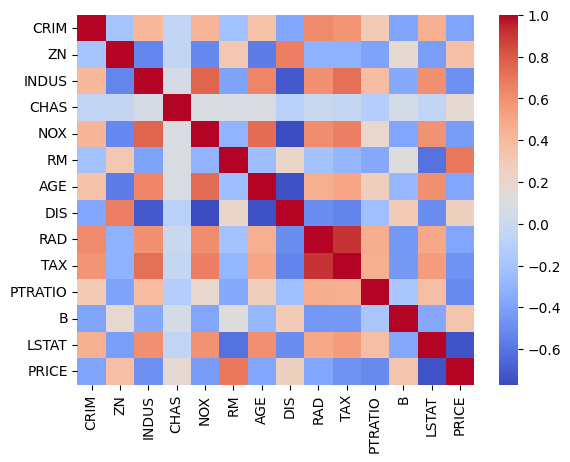

In [45]:
sns.heatmap(df.corr(),cmap = 'coolwarm')
plt.show()

In [46]:
''' separacion de '''

X = df.drop('PRICE',axis=1) #drop elimina la columna 
Y = df['PRICE'] # variable objetivo 


In [47]:
'''separacion en conjunto de entrenamiento y prueba  70% entremaniento y 30% para prueba '''
x_train,x_test,y_train,y_test = train_test_split(X,Y, test_size=0.3, random_state=42)

In [48]:
model = LinearRegression() ## LinearRegression tiene fit / predict
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [49]:
''' cuidar que los datos esten normalizados '''
print(model.intercept_,'\n')

model.coef_

31.631084035693547 



array([-1.33470103e-01,  3.58089136e-02,  4.95226452e-02,  3.11983512e+00,
       -1.54170609e+01,  4.05719923e+00, -1.08208352e-02, -1.38599824e+00,
        2.42727340e-01, -8.70223437e-03, -9.10685208e-01,  1.17941159e-02,
       -5.47113313e-01])

In [50]:
## predicciones del entrenamiento 
pred_train = model.predict(x_train)
residuos_train = y_train - pred_train

In [51]:
mae = mean_absolute_error(y_train,pred_train)
mse = mean_squared_error(y_train,pred_train)
rmse= np.sqrt(mse)
r2=r2_score(y_train,pred_train) # coeficiente de determinscion 

print('Evalucion en datos de entrenamient0 \n')
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R^2:{r2}')


Evalucion en datos de entrenamient0 

MAE: 3.3568267821682105
MSE: 22.545481487421423
RMSE: 4.748208239685937
R^2:0.7434997532004697


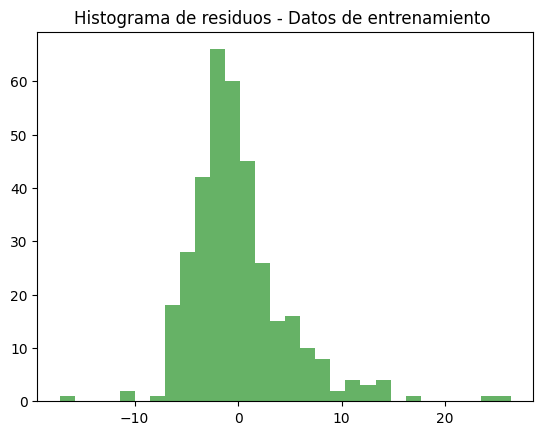

In [52]:
## Histograma de los residuos 
plt.hist(residuos_train,bins=30 , color='g',alpha = 0.6)
plt.title('Histograma de residuos - Datos de entrenamiento ')
plt.show()

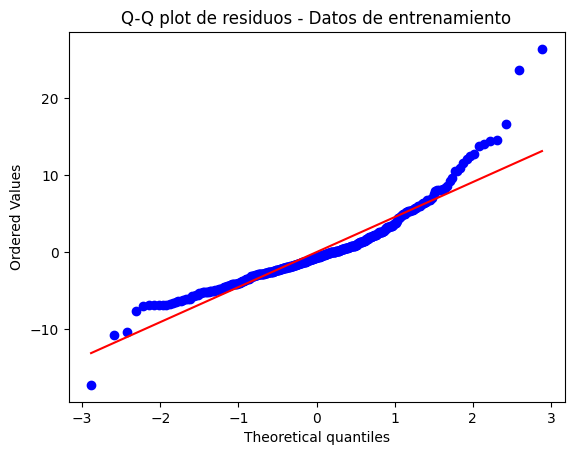

'comparamos los datos segun la regresion normal / posibles outliers '

In [53]:
# plot de cuantiles
from scipy.stats import probplot  

probplot(residuos_train, dist = 'norm', plot= plt)
plt.title('Q-Q plot de residuos - Datos de entrenamiento')
plt.show()

'''comparamos los datos segun la regresion normal / posibles outliers '''

In [54]:
#calculo de la prueba de shapiro wilk  
from scipy.stats import shapiro
stat,p_valor = shapiro(residuos_train)
print(f'Estadistico de Shapiro-Wilk: { stat} \n p-valor: {p_valor}') 
# se observo que los residuos no siguen una distribucion normal 

Estadistico de Shapiro-Wilk: 0.9067455567851997 
 p-valor: 5.850875389177117e-14


'buscamos que se sigan una varianza constant 0  / problemas de homocedasticidad '

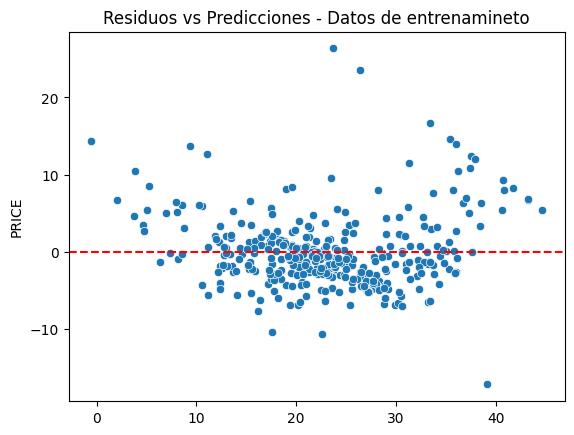

In [55]:
# residuos vs predicciones 
sns.scatterplot(x =pred_train, y=residuos_train )
plt.axhline(0 , color='red', linestyle='--')
plt.title('Residuos vs Predicciones - Datos de entrenamineto')

'''buscamos que se sigan una varianza constant 0  / problemas de homocedasticidad '''

In [56]:
y_pred = model.predict(x_test)

mae_test = mean_absolute_error(y_test,y_pred)
mse_test = mean_squared_error(y_test,y_pred)
r2_test = r2_score(y_test, y_pred) # coeficiente de determinacion 

print('Evalucion en datos de entrenamient0 \n')
print(f'MAE: {mae_test}')
print(f'MSE: {mse_test}')
print(f'RMSE: {mse_test}')
print(f'R^2:{r2_test}')

Evalucion en datos de entrenamient0 

MAE: 3.1627098714574147
MSE: 21.51744423117727
RMSE: 21.51744423117727
R^2:0.7112260057484925


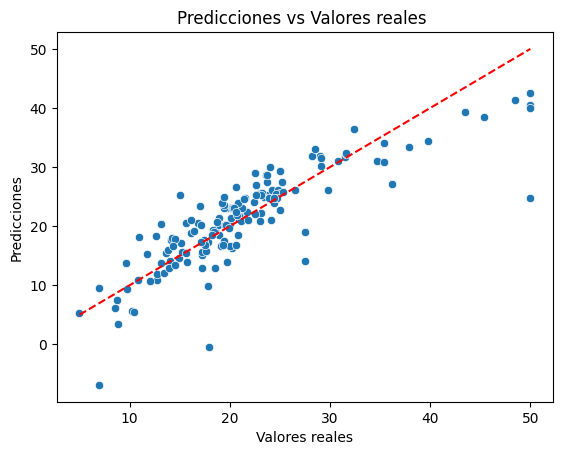

In [57]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Predicciones vs Valores reales ')
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)], color = 'red', linestyle = '--')
plt.show()

In [58]:
#Calculo de residuos en datos de prueba 
residuos_test = y_test - y_pred


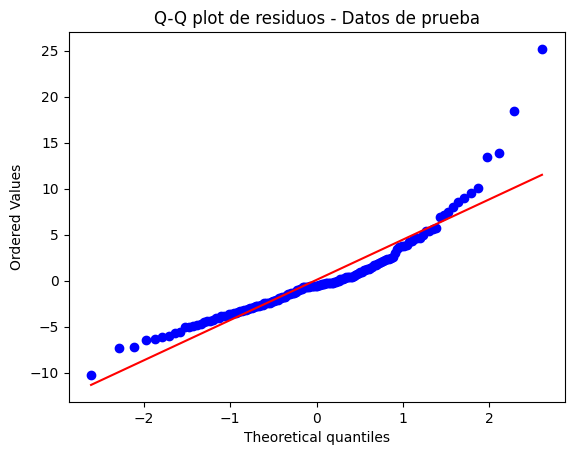

In [59]:
probplot(residuos_test,dist = 'norm',plot = plt)
plt.title('Q-Q plot de residuos - Datos de prueba')
plt.show()

In [60]:
#prueba de shapiro wilk en datos de prueba 
stat, p_valor = shapiro(residuos_test)
print(f'Estadisstico {stat} \nP-valor : {p_valor} ')

Estadisstico 0.8745830361759878 
P-valor : 5.079332696102525e-10 
